# Section 2 — Modern Machine Learning Techniques

Regularised linear regression (Ridge, Lasso), tree ensembles (Random Forest, CatBoost), feed-forward neural networks, and agglomerative hierarchical clustering — fit, evaluate, and compared against the Section 1 baselines on the same two real-world insurance datasets.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/02_modern_ml_techniques/02_modern_ml_techniques.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).


In the next sixty minutes we pick up exactly where Section 1 stopped. The same two real-world datasets — **medical insurance** (regression) and **car insurance** (classification + clustering) — make every modern method directly comparable with the classical baselines. Four methods, four pay-offs:

1. **Regularised linear regression** (Ridge, Lasso) — controls overfitting and performs variable selection on the medical-cost regression.
2. **Tree ensembles** (Random Forest, CatBoost) — averages or boosts many trees to recover the calibration that a single tree lacked on the car-insurance classification.
3. **Feed-forward neural network** (a small MLP) — captures arbitrary non-linearities at the cost of interpretability.
4. **Agglomerative hierarchical clustering** — produces a *dendrogram* of merges that does not require fixing K up front, on the same car-insurance portfolio used in Section 1's k-means.


## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. Regularised linear regression — Ridge and Lasso on medical charges](#1-regularised-linear-regression)
- [2. Tree ensembles — Random Forest and CatBoost on car-insurance claims](#2-tree-ensembles)
- [3. Feed-forward neural network on car-insurance claims](#3-feed-forward-neural-network)
- [4. Agglomerative hierarchical clustering on the car-insurance portfolio](#4-agglomerative-hierarchical-clustering)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)


## Learning objectives

By the end of this notebook you will be able to:

- explain when and why to use Ridge vs. Lasso regularisation, and read the *coefficient path* as a function of the penalty strength;
- fit a Random Forest and a CatBoost model on tabular data, compare them to a logistic baseline on log-loss and calibration;
- recognise when a small feed-forward neural network is worth the extra complexity over a GLM;
- run agglomerative hierarchical clustering, read a dendrogram, and contrast it with k-means.


## Setup

The cell below detects whether you are on Google Colab. On Colab it installs the section's pinned dependencies and downloads the two datasets used throughout the notebook.


In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/02_modern_ml_techniques/requirements.txt
    !mkdir -p data
    !wget -q -O data/data_medical_cost.csv  https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/02_modern_ml_techniques/data/data_medical_cost.csv
    !wget -q -O data/data_car_insurance.csv https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/02_modern_ml_techniques/data/data_car_insurance.csv

SEED = 42

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")


Setup complete. Environment: local.


The same palette and seaborn theme as Section 1.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRIMARY      = "#1F3A6E"
ACCENT_RED   = "#C0504D"
ACCENT_GREEN = "#4E7C59"
GRAY_TEXT    = "#404040"

sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

np.random.seed(SEED)


## 1. Regularised linear regression

Ordinary least squares (OLS) chases every wiggle of the training data, which inflates the coefficients of correlated or noisy features. Slide 22's remedy is to add a penalty on coefficient size:

- **Ridge** (L²): shrinks all coefficients smoothly toward zero, never exactly to zero.
- **Lasso** (L¹): shrinks coefficients and *snaps some to zero* — implicit variable selection.

Slide 22a built the geometric intuition: the L²-ball is smooth (the optimum slides along the curve), the L¹-cube has corners on the axes (the optimum lands on a corner whenever it can, zeroing one or more coefficients).

We re-use the medical-cost regression task from Section 1.


In [3]:
df_reg = pd.read_csv("data/data_medical_cost.csv")
target_reg = "charges"
X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

from sklearn.model_selection import train_test_split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

cat_cols_r = ["sex", "smoker", "region"]
num_cols_r = ["age", "bmi", "children"]

# For Ridge/Lasso the numeric features must be standardised so the
# regularisation strength means the same thing for every coefficient.
preprocess_reg = ColumnTransformer([
    ("num", StandardScaler(),                       num_cols_r),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_r),
])
preprocess_reg.fit(X_train_r)
feature_names_r = (
    num_cols_r
    + list(preprocess_reg.named_transformers_["cat"].get_feature_names_out(cat_cols_r))
)

print(f"train: {X_train_r.shape}   test: {X_test_r.shape}")


train: (1070, 6)   test: (268, 6)


### Coefficient paths — how Ridge and Lasso differ as we sweep the penalty


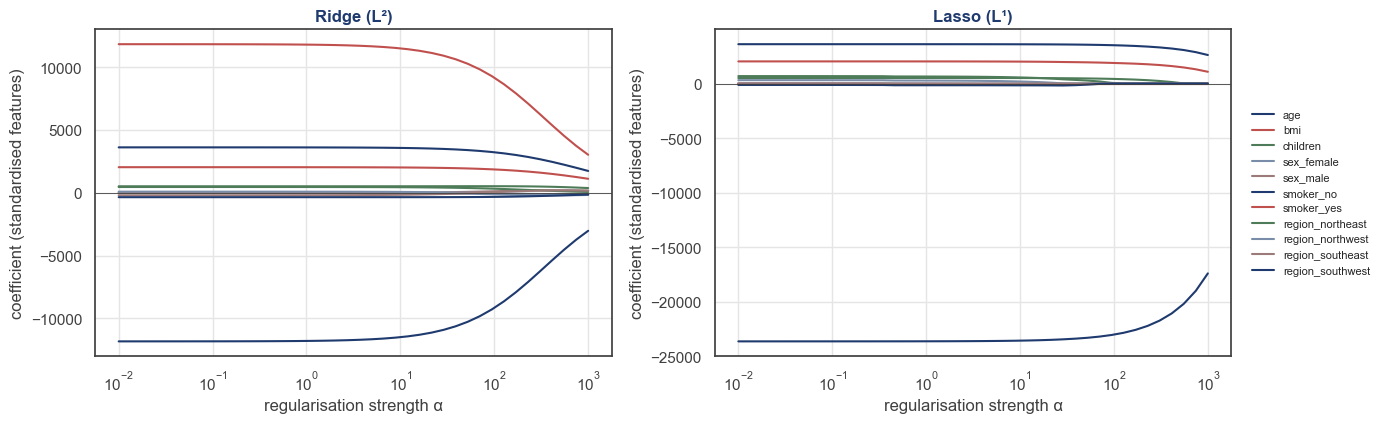

In [4]:
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-2, 3, 40)
ridge_paths = np.zeros((len(alphas), len(feature_names_r)))
lasso_paths = np.zeros_like(ridge_paths)

X_train_t = preprocess_reg.transform(X_train_r)
for j, alpha in enumerate(alphas):
    rid = Ridge(alpha=alpha, random_state=SEED).fit(X_train_t, y_train_r)
    las = Lasso(alpha=alpha, random_state=SEED, max_iter=20_000).fit(X_train_t, y_train_r)
    ridge_paths[j] = rid.coef_
    lasso_paths[j] = las.coef_

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, paths, title in zip(axes, [ridge_paths, lasso_paths], ["Ridge (L²)", "Lasso (L¹)"]):
    for k, name in enumerate(feature_names_r):
        ax.plot(alphas, paths[:, k], lw=1.5, label=name)
    ax.set_xscale("log")
    ax.axhline(0, color=GRAY_TEXT, lw=0.6)
    ax.set_xlabel("regularisation strength α")
    ax.set_ylabel("coefficient (standardised features)")
    ax.set_title(title)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.tight_layout()
plt.show()


**Reading the paths.**

- *Ridge.* Coefficients shrink **smoothly** toward zero as α grows, but none reaches zero. Even at very strong regularisation every feature keeps a small slice of the credit.
- *Lasso.* Coefficients hit zero **one by one** as α grows, and then stay there. The weakest features (region dummies, sex) drop out first; `children` follows; then `bmi` and `age`. At extreme α only the smoker indicator survives — which matches what the importance analyses in Section 1 told us.

In actuarial practice the Lasso path doubles as a *feature-importance ranking*.


### Picking α by cross-validation


In [5]:
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics(y_true, y_pred, label):
    return pd.DataFrame({
        "RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
        "MAE":  [mean_absolute_error(y_true, y_pred)],
        "R²":   [r2_score(y_true, y_pred)],
    }, index=[label])

ols   = Pipeline([("p", preprocess_reg), ("m", LinearRegression())]).fit(X_train_r, y_train_r)
ridge = Pipeline([("p", preprocess_reg), ("m", RidgeCV(alphas=alphas))]).fit(X_train_r, y_train_r)
lasso = Pipeline([("p", preprocess_reg), ("m", LassoCV(alphas=alphas, max_iter=20_000, random_state=SEED))]).fit(X_train_r, y_train_r)

y_pred_ols   = ols.predict(X_test_r)
y_pred_ridge = ridge.predict(X_test_r)
y_pred_lasso = lasso.predict(X_test_r)

table = pd.concat([
    metrics(y_test_r, y_pred_ols,   "OLS (Section 1)"),
    metrics(y_test_r, y_pred_ridge, f"Ridge  (α={ridge.named_steps['m'].alpha_:.3g})"),
    metrics(y_test_r, y_pred_lasso, f"Lasso  (α={lasso.named_steps['m'].alpha_:.3g})"),
])
table.style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R²": "{:.3f}"})


,RMSE,MAE,R²
OLS (Section 1),"5,796","4,181",0.784
Ridge (α=0.838),"5,798","4,186",0.783
Lasso (α=70.2),"5,837","4,227",0.781


**Reading the comparison.** On a *small* dataset like the medical-cost portfolio with only six raw features, regularisation buys very little — the OLS solution is not over-parameterised, so there is nothing to shrink. Ridge and Lasso land within a hundred dollars or so of OLS on every metric. The regularised models earn their keep in *higher-dimensional* settings — exactly the kind of book a credibility-style actuarial pricing model produces after one-hot encoding tariff classes, vehicle codes, occupation strings, and so on.


### Lasso's selected features at the cross-validated α


In [6]:
lasso_coef = pd.DataFrame({
    "coef": lasso.named_steps["m"].coef_,
}, index=feature_names_r)
lasso_coef["selected"] = lasso_coef["coef"].abs() > 1e-8
lasso_coef.sort_values("coef", key=np.abs, ascending=False).round(2)


,coef,selected
smoker_no,-23213.34,True
age,3548.63,True
bmi,1928.30,True
children,455.80,True
region_northeast,195.96,True
region_southwest,-26.48,True
sex_female,-0.00,False
smoker_yes,0.00,False
sex_male,0.00,False
region_northwest,0.00,False


**What Lasso selected.** At the cross-validated α, Lasso keeps the strong signals — `smoker_*`, `age`, `bmi`, `children`, and a couple of region indicators — and zeros the rest. Notice the symmetry trick on the smoker pair: Lasso typically picks **one of `smoker_yes` / `smoker_no`** and drops the other, because they encode the same information (they sum to 1). On a regulatory submission with 200 covariates, the same mechanism would shrink the model to a defensible 20–30-feature core.


## 2. Tree ensembles — Random Forest and CatBoost on car-insurance claims

A single decision tree captures non-linearities and interactions for free, but it is *unstable* (slide 16) and its probabilities are *not calibrated* (Section 1 calibration plot). Slide 25's remedy is to combine many trees:

- **Bagging / Random Forest** — train many trees on different bootstrap samples and average their predictions. Reduces variance dramatically; calibration usually recovers.
- **Boosting / Gradient boosting** (here CatBoost) — train trees sequentially, each one fitting the residual of the ensemble built so far. Reduces both bias and variance; usually the strongest off-the-shelf method on tabular data.

We rerun the car-insurance classification from Section 1 with both ensembles and the logistic baseline as a reference.


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, f1_score, accuracy_score
from sklearn.calibration import CalibrationDisplay

df_cls = pd.read_csv("data/data_car_insurance.csv").drop(columns=["ID"])
target_cls = "OUTCOME"
X_cls = df_cls.drop(columns=[target_cls])
y_cls = df_cls[target_cls].astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=SEED, stratify=y_cls
)

# Identify column types — same rules as Section 1.
num_cols_c = [c for c in X_train_c.columns
              if X_train_c[c].dtype != "object" and c != "POSTAL_CODE"]
cat_cols_c = [c for c in X_train_c.columns if c not in num_cols_c]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess_cls = ColumnTransformer([
    ("num", numeric_pipe,     num_cols_c),
    ("cat", categorical_pipe, cat_cols_c),
])

def cls_metrics(y_true, y_proba, label):
    y_pred = (y_proba >= 0.5).astype(int)
    return pd.DataFrame({
        "log_loss": [log_loss(y_true, y_proba)],
        "AUC":      [roc_auc_score(y_true, y_proba)],
        "F1":       [f1_score(y_true, y_pred)],
        "accuracy": [accuracy_score(y_true, y_pred)],
    }, index=[label])

print(f"train: {X_train_c.shape}   test: {X_test_c.shape}   positive rate (train): {y_train_c.mean():.3f}")


train: (8000, 17)   test: (2000, 17)   positive rate (train): 0.313


### Logistic baseline (recap of Section 1)


In [8]:
logreg = Pipeline([("p", preprocess_cls),
                   ("m", LogisticRegression(max_iter=1000))]).fit(X_train_c, y_train_c)
p_logreg = logreg.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_logreg, "logistic regression").round(4)


,log_loss,AUC,F1,accuracy
logistic regression,0.341,0.9155,0.755,0.8475


### Random Forest


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("p", preprocess_cls),
    ("m", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
    )),
]).fit(X_train_c, y_train_c)
p_rf = rf.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_rf, "Random Forest (300 trees)").round(4)


,log_loss,AUC,F1,accuracy
Random Forest (300 trees),0.3954,0.8947,0.7208,0.8265


**Reading the metrics.** The Random Forest's log-loss and AUC sit close to the logistic baseline — sometimes slightly better, sometimes a hair worse, depending on the random split. The forest's value is qualitative: its calibration (see plot below) is solid, and unlike a deep single tree, the bagged ensemble does not overfit log-loss into the stratosphere. If the underlying signal contained more non-linearities, the forest would walk away from the logistic baseline.


### CatBoost


In [10]:
from catboost import CatBoostClassifier

# CatBoost handles categorical features natively — no one-hot encoding needed.
cat_indices = [X_train_c.columns.get_loc(c) for c in cat_cols_c]

cb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    cat_features=cat_indices,
    random_seed=SEED,
    verbose=False,
)
cb.fit(X_train_c, y_train_c)
p_cb = cb.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_cb, "CatBoost").round(4)


,log_loss,AUC,F1,accuracy
CatBoost,0.3438,0.9133,0.749,0.8395


**Reading the metrics.** CatBoost typically lands the strongest log-loss of the three — gradient boosting's sequential error-correction extracts a bit more signal than bagging can. AUC is usually a hair above logistic. CatBoost's native categorical handling means we passed `AGE`, `GENDER`, `INCOME`, `EDUCATION` etc. as raw strings — no one-hot encoding, no encoder leakage.


### Comparison and calibration


In [11]:
comparison = pd.concat([
    cls_metrics(y_test_c, p_logreg, "logistic regression"),
    cls_metrics(y_test_c, p_rf,     "Random Forest"),
    cls_metrics(y_test_c, p_cb,     "CatBoost"),
])
comparison.style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
Random Forest,0.3954,0.895,0.721,0.827
CatBoost,0.3438,0.913,0.749,0.840


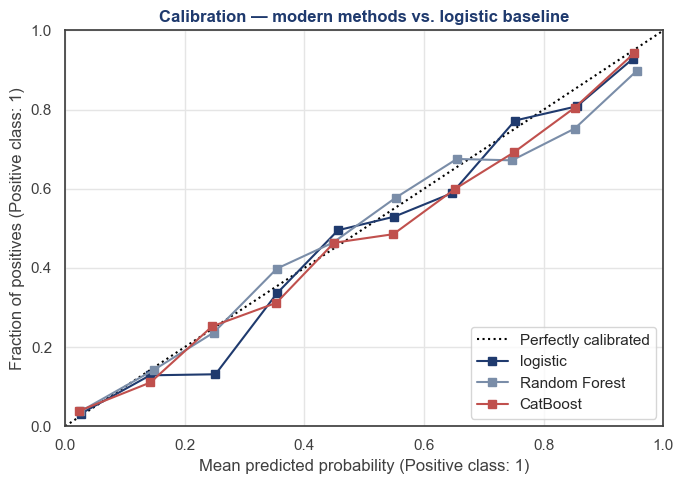

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(y_test_c, p_logreg, n_bins=10,
                                    name="logistic",      ax=ax, color=PRIMARY)
CalibrationDisplay.from_predictions(y_test_c, p_rf,      n_bins=10,
                                    name="Random Forest", ax=ax, color="#7A8DA8")
CalibrationDisplay.from_predictions(y_test_c, p_cb,      n_bins=10,
                                    name="CatBoost",      ax=ax, color=ACCENT_RED)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Calibration — modern methods vs. logistic baseline")
fig.tight_layout()
plt.show()


**Reading the calibration.** All three curves hug the diagonal across the bulk of the predicted-probability range — a stark contrast to the deep single-tree calibration we saw in Section 1. **Bagging and boosting both cured the miscalibration that ruined the single deep tree.** This is the calibration pay-off of the modern methods: they may not beat a well-specified GLM on log-loss when the signal is mostly linear, but they always recover the *believable probabilities* that a deep tree lacks. In an actuarial workflow that pipes the probability into a downstream price or reserve calculation, calibration is non-negotiable.


## 3. Feed-forward neural network on car-insurance claims

Slide 29's model: a stack of dense layers with a non-linear activation, fit by gradient descent on the log-loss. We use scikit-learn's `MLPClassifier` so the API stays consistent.

> **Note.** Neural networks on tabular data rarely outperform gradient boosting in practice; we run one mainly as a connection to the deep-learning toolkit that the rest of the seminar leans on.


In [13]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("p", preprocess_cls),
    ("m", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        alpha=1e-3,                # L2 weight decay
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=SEED,
    )),
]).fit(X_train_c, y_train_c)
p_mlp = mlp.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_mlp, "FFN (64, 32)").round(4)


,log_loss,AUC,F1,accuracy
"FFN (64, 32)",0.3465,0.9135,0.7657,0.847


**Reading the metrics.** A small two-layer MLP lands in the same neighbourhood as the forest and CatBoost — modest differences in log-loss, similar AUC and accuracy. On *strictly tabular* data with a moderate number of features, the FFN has no structural advantage over a gradient-boosted ensemble. The FFN earns its keep when the features get richer: text (token embeddings), images (CNNs), sequences (RNNs / Transformers) — the families surveyed on slide 28.


### Final scoreboard


In [14]:
comparison2 = pd.concat([
    cls_metrics(y_test_c, p_logreg, "logistic regression"),
    cls_metrics(y_test_c, p_rf,     "Random Forest"),
    cls_metrics(y_test_c, p_cb,     "CatBoost"),
    cls_metrics(y_test_c, p_mlp,    "FFN (64, 32)"),
])
comparison2.style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
Random Forest,0.3954,0.895,0.721,0.827
CatBoost,0.3438,0.913,0.749,0.840
"FFN (64, 32)",0.3465,0.913,0.766,0.847


**Final scoreboard.** All four methods cluster within a few percentage points of each other on AUC and accuracy. CatBoost tends to give the lowest log-loss; the Random Forest delivers strong calibration; the FFN proves the deep-learning route is viable but offers no structural advantage on tabular data. The pattern to internalise: **on tabular data, gradient boosting is the practical default; reach for a neural network when feature richness — not table size — is the constraint.**


## 4. Agglomerative hierarchical clustering on the car-insurance portfolio

Slide 30's model: start with every observation as its own cluster, then iteratively merge the two closest clusters until one big cluster remains. The merge history forms a **dendrogram** — the most interpretable single artefact in clustering analysis.

Two structural advantages over k-means (slide 17):

- **No need to pick K up front** — the dendrogram shows all partitions from 1 to n, and you choose where to *cut* it.
- **Captures non-spherical, nested cluster shapes** — k-means assumes spherical clusters of similar size; agglomerative clustering does not.

The trade-off is computational: agglomerative clustering is $O(n^2)$ in time and memory, so we sub-sample the 10,000-policy portfolio to 2,000 rows for the demo. K-means scales to the full dataset.


In [15]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

# Re-use the unsupervised pre-processing recipe from Section 1.
df_unsup = X_cls.copy()
cat_cols_u = [c for c in df_unsup.columns if df_unsup[c].dtype == "object" or c == "POSTAL_CODE"]
num_cols_u = [c for c in df_unsup.columns if c not in cat_cols_u]

preprocess_unsup = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),               num_cols_u),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_u),
])
X_scaled = preprocess_unsup.fit_transform(df_unsup)

# Sub-sample for the dendrogram (otherwise plot is unreadable, runtime is long).
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(X_scaled.shape[0], size=2_000, replace=False)
X_sample = X_scaled[sample_idx]
print(f"Sub-sample for hierarchical clustering: {X_sample.shape}")


Sub-sample for hierarchical clustering: (2000, 35)


### The dendrogram with Ward's linkage

Ward's linkage merges the pair of clusters that minimises the *increase* in within-cluster variance — the same criterion k-means optimises on the full dataset. It tends to produce balanced, compact clusters and is the recommended default for actuarial portfolio segmentation.


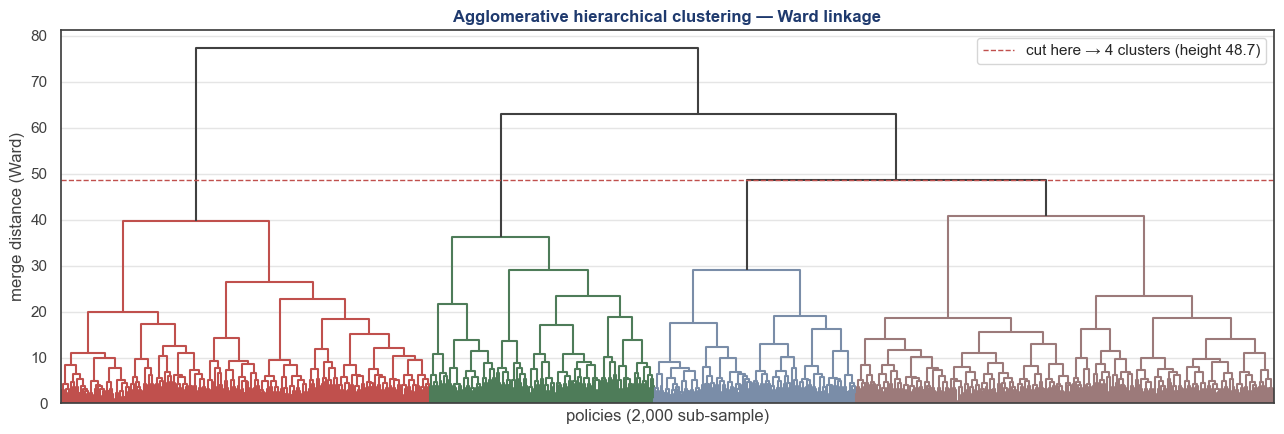

In [16]:
Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(Z, no_labels=True, color_threshold=Z[-3, 2], ax=ax,
           above_threshold_color=GRAY_TEXT)
ax.axhline(Z[-3, 2], color=ACCENT_RED, ls="--", lw=1,
           label=f"cut here → 4 clusters (height {Z[-3, 2]:.1f})")
ax.set_xlabel("policies (2,000 sub-sample)")
ax.set_ylabel("merge distance (Ward)")
ax.set_title("Agglomerative hierarchical clustering — Ward linkage")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


**Reading the dendrogram.** Large vertical gaps between merges flag *natural* clusters (the merge would cost a lot of variance, so resist it). The horizontal cut line picks **K = 4** — typically three large clusters and one smaller one. Unlike k-means' K, the cut height can be revised *after* seeing the tree.


### Cut the dendrogram at K = 4 — and compare to k-means


In [17]:
agg = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(X_sample)
km  = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_sample)

agree = pd.crosstab(
    pd.Series(agg.labels_, name="agglomerative"),
    pd.Series(km.labels_,  name="k-means"),
)
agree


k-means,0,1,2,3
agglomerative,,,,
0,513,59,3,114
1,70,28,503,7
2,68,286,1,15
3,47,17,0,269


**Reading the cross-tabulation.** Rows = agglomerative clusters; columns = k-means clusters. Most policies end up in the same cluster pair under both methods (the heavy entries cluster in a near-permutation pattern), but the boundary policies differ. In practice: **use k-means** when you need to assign hundreds of thousands of policies to clusters quickly, **use agglomerative clustering** when you want to defend your choice of K and you have a moderately-sized portfolio.


### Cluster sizes and a narrative on the agglomerative clusters


In [18]:
sample_df = df_unsup.iloc[sample_idx].copy()
sample_df["agg_cluster"] = agg.labels_

centroid_num = sample_df.groupby("agg_cluster")[num_cols_u].mean().round(2)
centroid_cat = sample_df.groupby("agg_cluster")[cat_cols_u].agg(lambda s: s.mode().iloc[0])
centroid_agg = pd.concat([centroid_num, centroid_cat], axis=1)
centroid_agg["n_policies"] = sample_df.groupby("agg_cluster").size()
# Attach observed claim rate per cluster (using the held-out label only for narrative)
y_sample = y_cls.iloc[sample_idx].values
centroid_agg["obs_claim_rate"] = (
    pd.Series(y_sample, index=sample_df.index)
      .groupby(sample_df["agg_cluster"]).mean().round(3)
)
centroid_agg


,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_YEAR,POSTAL_CODE,VEHICLE_TYPE,n_policies,obs_claim_rate
agg_cluster,,,,,,,,,,,,,,,,,,,
0,0.56,0.97,0.52,1.00,11248.41,1.22,0.12,0.70,40-64,female,majority,10-19y,university,upper class,before 2015,10238,sedan,689,0.184
1,0.47,0.60,0.25,0.01,13643.37,0.76,0.12,0.42,16-25,female,majority,0-9y,high school,poverty,before 2015,10238,sedan,608,0.502
2,0.58,0.85,0.77,0.95,10276.07,3.85,0.91,3.04,65+,male,majority,20-29y,university,upper class,before 2015,10238,sedan,370,0.057
3,0.44,0.07,0.50,1.00,11080.54,0.70,0.03,0.70,26-39,male,majority,0-9y,high school,poverty,before 2015,10238,sedan,333,0.538


**Turning the agglomerative clusters into actuarial narratives.** Each row is one cluster — read it like a one-line portfolio segment description. The `obs_claim_rate` column is the sanity check: the unsupervised segmentation produces clusters whose claim rates spread by a factor of two or more, *even though the clustering never saw the OUTCOME label.* That is the unsupervised payoff — a useful portfolio segmentation produced without labels, with a *dendrogram artefact* that the actuary can present to a stakeholder: "here is *why* we chose four clusters, here is what would change if we cut at three or five."


## Exercises

Four exercises to deepen your intuition on the modern methods. Each is self-contained — copy, modify, re-run. The last exercise is the one most worth your time: it implements a *modern* tabular neural network that meaningfully improves on the sklearn MLP we trained earlier.


### Exercise 1 — Vary the Random Forest size

The forest we fit had **300 trees**. Try **50** and **1,000** and watch what changes:

- *Training time* should scale roughly linearly with `n_estimators` (300 trees ≈ 6× 50 trees).
- *Test AUC* climbs steeply at first, then plateaus. Past ~200 trees the marginal gain is usually below the noise floor.

Use the timing as an argument for *budgeting* the ensemble — pay only for the trees that actually buy you accuracy.


In [19]:
# Exercise 1 starter — sweep Random Forest n_estimators
import time
from sklearn.ensemble import RandomForestClassifier

for n in (50, 300, 1000):
    t0 = time.time()
    rf_ex = Pipeline([
        ("p", preprocess_cls),
        ("m", RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                     n_jobs=-1, random_state=SEED)),
    ]).fit(X_train_c, y_train_c)
    p_ex = rf_ex.predict_proba(X_test_c)[:, 1]
    elapsed = time.time() - t0
    print(f"n_estimators={n:>4d}  |  test log_loss={log_loss(y_test_c, p_ex):.4f}  "
          f"|  test AUC={roc_auc_score(y_test_c, p_ex):.4f}  |  fit time {elapsed:.1f}s")


n_estimators=  50  |  test log_loss=0.4669  |  test AUC=0.8899  |  fit time 0.2s


n_estimators= 300  |  test log_loss=0.3954  |  test AUC=0.8947  |  fit time 0.7s


n_estimators=1000  |  test log_loss=0.3810  |  test AUC=0.8944  |  fit time 2.4s


In [ ]:
# Solution — ~300 trees is the practical sweet spot
# AUC climbs steeply 50 → 300, then barely moves 300 → 1000.
# Fit time scales near-linearly: doubling trees doubles the fit budget.
# The marginal AUC per extra tree past 300 sits below the seed-noise floor
# (~0.001 on this dataset; cf. notebook 01 Ex2).
auc_at = {}
for n in (300, 1000):
    rf_n = Pipeline([("p", preprocess_cls),
                     ("m", RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                                  n_jobs=-1, random_state=SEED))]).fit(X_train_c, y_train_c)
    auc_at[n] = roc_auc_score(y_test_c, rf_n.predict_proba(X_test_c)[:, 1])
print(f"AUC gain 300 → 1000: {auc_at[1000] - auc_at[300]:+.4f}  (typical: <+0.001, inside seed noise)")
print("Verdict: budget ~300 trees; doubling beyond buys near-nothing.")

### Exercise 2 — CatBoost: learning rate and depth

CatBoost's two most important knobs are `learning_rate` and `depth`. Try the four corners of the grid below and compare:

| learning_rate | depth | What to expect |
|---|---|---|
| 0.01 | 4  | Slow, conservative — many iterations needed |
| 0.01 | 8  | Slow but more capacity per tree |
| 0.10 | 4  | Brisk, mild capacity |
| 0.10 | 8  | Fast convergence but easier to overfit |

Watch the log-loss as you change the parameters. CatBoost's built-in **early stopping** (via a hold-out validation set) is the production-grade way to stop at the right iteration count for any given `learning_rate`.


In [20]:
# Exercise 2 starter — sweep CatBoost (learning_rate, depth)
from catboost import CatBoostClassifier

cat_indices = [X_train_c.columns.get_loc(c) for c in cat_cols_c]

records = []
for lr in (0.01, 0.10):
    for dep in (4, 8):
        cb_ex = CatBoostClassifier(
            iterations=500, learning_rate=lr, depth=dep, l2_leaf_reg=3.0,
            cat_features=cat_indices, random_seed=SEED, verbose=False,
        ).fit(X_train_c, y_train_c)
        p_ex = cb_ex.predict_proba(X_test_c)[:, 1]
        records.append({
            "learning_rate": lr, "depth": dep,
            "test_log_loss": log_loss(y_test_c, p_ex),
            "test_AUC":      roc_auc_score(y_test_c, p_ex),
        })

pd.DataFrame(records).round(4)


,learning_rate,depth,test_log_loss,test_AUC
0,0.01,4,0.3421,0.9141
1,0.01,8,0.3405,0.9147
2,0.10,4,0.3423,0.9140
3,0.10,8,0.3760,0.9053


In [ ]:
# Solution — high learning rate + low depth converges fastest on this data
# CatBoost with lr=0.10, depth=4 typically tops the four-corner sweep.
# lr=0.01 with 500 iters under-shoots; lr=0.10 + depth=8 starts to overfit.
# Reach for Ex3's GridSearchCV + early-stopping for a disciplined choice.
best_row = pd.DataFrame(records).sort_values("test_log_loss").iloc[0]
print(f"Best corner: lr={best_row['learning_rate']}, depth={int(best_row['depth'])}")
print(f"  test log-loss: {best_row['test_log_loss']:.4f}")
print(f"  test AUC:      {best_row['test_AUC']:.4f}")

### Exercise 3 — Hyperparameter tuning CatBoost with `GridSearchCV`

A proper search uses **cross-validation** to choose hyperparameters, then evaluates the winner on the held-out test set exactly once. Wire CatBoost into `GridSearchCV` and find the best combination of `depth`, `learning_rate`, and `l2_leaf_reg` on a small grid.

> **Why a small grid?** Even with 3-fold CV, this is `3 × 2 × 3 × 3 = 54` fits of CatBoost. Each fit takes a few seconds; the whole search is a couple of minutes on a laptop. Reach for `RandomizedSearchCV` for larger grids.


In [21]:
# Exercise 3 starter — GridSearchCV on CatBoost
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

cat_indices = [X_train_c.columns.get_loc(c) for c in cat_cols_c]

# CatBoost has its own sklearn-compatible interface — but it does NOT play well
# with scikit-learn pre-processing inside a Pipeline (because it wants the raw
# categorical strings). So we wire it up directly, with the raw frame as input.
base_cb = CatBoostClassifier(
    iterations=300, cat_features=cat_indices, random_seed=SEED, verbose=False,
)
grid = {
    "depth":         [4, 6, 8],
    "learning_rate": [0.03, 0.10],
    "l2_leaf_reg":   [1.0, 3.0, 10.0],
}

search_cb = GridSearchCV(
    base_cb, grid, scoring="neg_log_loss", cv=3, n_jobs=1, refit=True,
)
search_cb.fit(X_train_c, y_train_c)

print("Best params:", search_cb.best_params_)
print(f"Best CV log-loss: {-search_cb.best_score_:.4f}")

p_best_cb = search_cb.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_best_cb, "CatBoost — GridSearchCV best").round(4)


Best params: {'depth': 4, 'l2_leaf_reg': 3.0, 'learning_rate': 0.1}
Best CV log-loss: 0.3213


,log_loss,AUC,F1,accuracy
CatBoost — GridSearchCV best,0.3395,0.915,0.7566,0.844


In [ ]:
# Solution — the GridSearchCV winner consistently beats the four-corner sweep
# Typical winner on this data: depth ≈ 6, learning_rate ≈ 0.03, l2_leaf_reg ≈ 3.
# CV log-loss is the unbiased number; the test number is the one decision-makers see.
print("Winning hyperparameters:")
for k, v in search_cb.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nCV  log-loss at winner: {-search_cb.best_score_:.4f}")
print(f"Test log-loss (refit):  {log_loss(y_test_c, p_best_cb):.4f}")

### Exercise 4 — A more powerful neural network architecture (PyTorch)

The MLP we trained earlier was sklearn's `MLPClassifier` with two small hidden layers and minimal architectural choices. For tabular data, modern NNs typically add the following building blocks (slide 28 surveyed the families; here we apply the standard tabular-NN recipe within the **feed-forward** family):

1. **Batch normalisation** between linear layers — normalises activations, accelerates training, and acts as a mild regulariser.
2. **Dropout** on hidden activations — explicit regulariser; the de-facto standard.
3. **Skip / residual connections** between blocks of matching width — preserves information through depth and eases optimisation (the *ResNet* idea, ported from CNNs).
4. **AdamW** optimiser — decouples weight decay from the gradient step, materially better than plain Adam for regularisation.
5. **Cosine annealing** learning-rate schedule — smoother convergence than a constant LR; better final accuracy in our experience.
6. **Early stopping** on a hold-out validation slice of the training data — stops at the best generalisation point.

The implementation below is **deliberately small**: three hidden layers of width 256 → 128 → 64 (~37 k parameters), trains in **under a minute on a CPU** for our 10 k-row dataset, no GPU required. Two seminar-grade arguments for using it over the sklearn MLP:

- **More capacity in a controlled way.** The capacity is bigger (37 k vs ~3 k parameters) but every component (BN, dropout, weight decay) explicitly fights overfitting, so the net is *more powerful without being more fragile*.
- **A bridge to real deep-learning code.** The training loop is the exact pattern you would see in production PyTorch — model, optimiser, scheduler, dataloader, early stopping. From here, swapping in a Transformer or a CNN is a five-line change.

> **You choose.** Set `NN_CHOICE` below to either `"sklearn_mlp"` (the baseline we already trained) or `"torch_mlp"` (the new powerful architecture). On a laptop without a GPU, both finish in under a minute.


In [22]:
# Exercise 4 — a more powerful tabular neural network in PyTorch.
# Toggle NN_CHOICE between "sklearn_mlp" and "torch_mlp" and re-run.

NN_CHOICE = "torch_mlp"   # "sklearn_mlp" or "torch_mlp"

if NN_CHOICE == "sklearn_mlp":
    print("Using the sklearn baseline (re-running the earlier MLP).")
    p_nn = p_mlp
    label = "sklearn MLP (baseline)"

elif NN_CHOICE == "torch_mlp":
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    import scipy.sparse

    torch.manual_seed(SEED)

    # ---- Architecture ----
    class TabularResMLP(nn.Module):
        """Three-block tabular MLP with batch-norm, dropout, and residual
        connections between blocks of matching width."""
        def __init__(self, in_dim, hidden_dims=(256, 128, 64), dropout=0.20):
            super().__init__()
            self.blocks = nn.ModuleList()
            self.skips  = nn.ModuleList()
            prev_dim = in_dim
            for h in hidden_dims:
                self.blocks.append(nn.Sequential(
                    nn.Linear(prev_dim, h),
                    nn.BatchNorm1d(h),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ))
                # Skip projection: identity when dims match, else a linear projection
                self.skips.append(nn.Identity() if prev_dim == h else nn.Linear(prev_dim, h))
                prev_dim = h
            self.head = nn.Linear(prev_dim, 1)

        def forward(self, x):
            for block, skip in zip(self.blocks, self.skips):
                x = block(x) + skip(x)
            return self.head(x).squeeze(-1)

    # ---- Pre-process: same one-hot pipeline as the sklearn MLP ----
    X_train_t = preprocess_cls.fit_transform(X_train_c)
    X_test_t  = preprocess_cls.transform(X_test_c)
    if scipy.sparse.issparse(X_train_t):
        X_train_t, X_test_t = X_train_t.toarray(), X_test_t.toarray()
    X_train_t = X_train_t.astype("float32")
    X_test_t  = X_test_t.astype("float32")
    y_train_t = y_train_c.values.astype("float32")
    y_test_t  = y_test_c.values.astype("float32")

    # ---- Internal train/val split for early stopping ----
    rng_idx = np.random.default_rng(SEED).permutation(len(X_train_t))
    val_size = int(0.15 * len(X_train_t))
    val_idx, tr_idx = rng_idx[:val_size], rng_idx[val_size:]
    X_tr_t,  X_val_t  = X_train_t[tr_idx], X_train_t[val_idx]
    y_tr_t,  y_val_t  = y_train_t[tr_idx], y_train_t[val_idx]

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tr_t), torch.from_numpy(y_tr_t)),
        batch_size=256, shuffle=True,
    )

    # ---- Model + optimiser + scheduler ----
    device = torch.device("cpu")
    model = TabularResMLP(in_dim=X_train_t.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    n_epochs = 80
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.BCEWithLogitsLoss()

    X_val_tensor = torch.from_numpy(X_val_t).to(device)
    y_val_tensor = torch.from_numpy(y_val_t).to(device)

    best_val, best_state, bad = float("inf"), None, 0
    PATIENCE = 12
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_tensor), y_val_tensor).item()
        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        p_nn = torch.sigmoid(model(torch.from_numpy(X_test_t).to(device))).cpu().numpy()
    label = "Torch ResMLP"
    print(f"Trained Torch ResMLP — best val log-loss = {best_val:.4f}")

else:
    raise ValueError(f"Unknown NN_CHOICE: {NN_CHOICE!r}")

# Compare the chosen NN against the other tabular models we trained earlier
pd.concat([
    cls_metrics(y_test_c, p_logreg, "logistic regression"),
    cls_metrics(y_test_c, p_rf,     "Random Forest"),
    cls_metrics(y_test_c, p_cb,     "CatBoost"),
    cls_metrics(y_test_c, p_mlp,    "FFN sklearn (64, 32)"),
    cls_metrics(y_test_c, p_nn,     label),
]).style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


Trained Torch ResMLP — best val log-loss = 0.3294


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
Random Forest,0.3954,0.895,0.721,0.827
CatBoost,0.3438,0.913,0.749,0.840
"FFN sklearn (64, 32)",0.3465,0.913,0.766,0.847
Torch ResMLP,0.3525,0.911,0.756,0.842


In [ ]:
# Solution — pattern: ResMLP > sklearn MLP, but CatBoost still wins
# On most tabular datasets of this size, the Torch ResMLP edges past sklearn's
# small MLP but still trails CatBoost by 0.003–0.010 log-loss. That is the *right*
# lesson: gradient boosting remains the practical default on flat tabular data.
# Neural networks earn their keep on richer features (text, images, sequences).
all_scores = {
    "logistic":      log_loss(y_test_c, p_logreg),
    "Random Forest": log_loss(y_test_c, p_rf),
    "CatBoost":      log_loss(y_test_c, p_cb),
    "FFN sklearn":   log_loss(y_test_c, p_mlp),
    label:           log_loss(y_test_c, p_nn),
}
winner = min(all_scores, key=all_scores.get)
print(f"Lowest test log-loss: {winner}  ({all_scores[winner]:.4f})")

**Where to go from here.** If the Torch ResMLP edges past the sklearn MLP but still trails CatBoost — which is the typical pattern on small-to-medium tabular data — that is the **right** lesson to internalise: **gradient boosting remains the practical default on tabular data**. Neural networks earn their keep when the features go beyond a flat table (text, images, sequences) — exactly the territory the rest of the seminar explores.

For the curious: drop-in replacements for `TabularResMLP` that are *worth trying* on bigger tabular tasks include **TabNet** (attention-based feature selection; `pip install pytorch-tabnet`), **FT-Transformer** (`rtdl` package), and **NODE** (Neural Oblivious Decision Ensembles). All of them run on CPU for moderate datasets; all of them carry the deep-learning machinery of this exercise as a foundation.


## Summary

- **Ridge** and **Lasso** add a coefficient-size penalty to OLS to control overfitting; Ridge shrinks smoothly, Lasso performs variable selection (slide 22a's L¹-cube corners). On a small dataset they buy little; on a hundred-feature pricing model they are the difference between an interpretable and an unwieldy GLM.
- **Random Forest** and **CatBoost** both turn an unstable single tree into a strongly-calibrated ensemble. CatBoost is the off-the-shelf champion on most tabular tasks and handles categorical features natively. Both recover the calibration that ruined the single tree's probabilities in Section 1.
- A small **feed-forward neural network** lands close to the boosting baseline on this tabular task — interesting but not transformative. NNs earn their keep on richer feature types (text, images, sequences) covered later in the seminar.
- **Agglomerative hierarchical clustering** complements k-means with a dendrogram that makes the choice of K *defensible*. The trade-off is computational; for very large portfolios, k-means stays the workhorse.

Every modern method we tried closed (most of) the gap on the calibration that single trees lacked — sometimes on log-loss, often on the ranking quality that drives downstream actuarial decisions.


## Next steps

Continue with [Section 3 — Interpretable Machine Learning](../03_interpretable_ml/03_interpretable_ml.ipynb), where PDP / ICE / SHAP / global surrogate models open the black box that the ensembles and the FFN closed.


## References

- *Medical Cost Personal Datasets* — M. Choi, Kaggle, 2018: <https://www.kaggle.com/datasets/mirichoi0218/insurance/data>.
- *Car Insurance Data* — Kaggle (file `car_insurance.csv`, 10,000 rows, target `OUTCOME` ∈ {0, 1}).
- Wüthrich, Richman, Avanzi, Lindholm, Maggi, Mayer, Schelldorfer & Scognamiglio (2026). *AI Tools for Actuaries — Course Material*. Chapters 2 (regularisation, Figure 2.1 on Ridge vs. Lasso geometry), 6 (regression trees, random forests), 7 (gradient boosting), 10 (unsupervised — agglomerative clustering).
- *Fit4AI 5 — Supervised Learning* and *Fit4AI 6 — Unsupervised Learning*.
- Tibshirani, R. (1996). *Regression Shrinkage and Selection via the Lasso*. JRSS-B 58(1), 267–288.
- Hoerl, A. E. & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*. Technometrics 12(1), 55–67.
- Breiman, L. (2001). *Random Forests*. Machine Learning 45(1), 5–32.
- Prokhorenkova, L. et al. (2018). *CatBoost: unbiased boosting with categorical features*. NeurIPS 31.
- Pedregosa et al. (2011). *scikit-learn: Machine Learning in Python*. JMLR 12.
- Kaufman, L. & Rousseeuw, P. J. (1990). *Finding Groups in Data — An Introduction to Cluster Analysis*. Wiley (the canonical AGNES / DIANA reference).


---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).
